In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAy'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
#| echo: false
df = pd.read_csv("ressources_tp/netflix_titles.csv")
print(f"✅ Dataset chargé : {len(df)} lignes, {df.shape[1]} colonnes")

✅ Dataset chargé : 8015 lignes, 12 colonnes


In [4]:
#| eval: false
# Charger le dataset
df = pd.read_csv("ressources_tp/netflix_titles.csv")
print(f"✅ Dataset chargé : {len(df)} lignes, {df.shape[1]} colonnes")

In [5]:
#| eval: false
# TODO: Étape 1.1

In [6]:
# 1. Aperçu
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Lost Kingdom,NaN,"Ravi Petit, Amélie Rossi, Olivier García, Amél...",Turkey,"March 21, 2020",1988,TV-MA,71 min,"Action & Adventure, Anime Series, TV Dramas",A mysterious story about family.
1,s2,Movie,The Final Love,Raj Suzuki,"David Andersen, Camila Tanaka, Yuki Andersen, ...",Germany,"November 22, 2011",2011,TV-MA,108 min,"Kids' TV, International Movies",A heartwarming story about adventure.
2,s3,Movie,Kingdom: Final Fire,Chen Rodriguez,"Felipe García, Isabella Rossi, Camila Suzuki, ...",United States,"February 10, 2015",2015,TV-14,105 min,Kids' TV,A hilarious story about revenge.
3,s4,Movie,House of Fire,Kwame Yamamoto,"Olivier Khan, Tom López, Yuki López, Chloé Tan...",Australia,"April 23, 2022",1991,TV-MA,78 min,"TV Horror, Anime Series",A gripping story about family.
4,s5,Movie,Perfect Journey,Ravi Müller,"Kwame García, Isabella López, Lin Kim, Yuki Ro...","United Kingdom, China","March 24, 2021",2006,TV-14,109 min,"Docuseries, Thrillers",A thrilling story about friendship.


In [7]:
# 2. Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8015 entries, 0 to 8014
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8015 non-null   str  
 1   type          8015 non-null   str  
 2   title         8015 non-null   str  
 3   director      6926 non-null   str  
 4   cast          7706 non-null   str  
 5   country       7855 non-null   str  
 6   date_added    7895 non-null   str  
 7   release_year  8015 non-null   int64
 8   rating        8015 non-null   str  
 9   duration      8015 non-null   str  
 10  listed_in     8015 non-null   str  
 11  description   8015 non-null   str  
dtypes: int64(1), str(11)
memory usage: 751.5 KB


In [8]:
# 3. Describe
df.describe()

,release_year
count,8015.000000
mean,2013.639426
std,8.550456
min,1981.000000
25%,2008.000000
50%,2015.000000
75%,2021.000000
max,2024.000000


In [9]:
# 4. Valeurs manquantes (triées)
na_counts = df.isna().sum().sort_values(ascending=False)
print("Valeurs manquantes par colonne :")
print(na_counts[na_counts > 0])
print(f"\nProportion : {(na_counts / len(df) * 100).round(2).to_dict()}")

Valeurs manquantes par colonne :
director      1089
cast           309
country        160
date_added     120
dtype: int64

Proportion : {'director': 13.59, 'cast': 3.86, 'country': 2.0, 'date_added': 1.5, 'title': 0.0, 'type': 0.0, 'show_id': 0.0, 'release_year': 0.0, 'rating': 0.0, 'duration': 0.0, 'listed_in': 0.0, 'description': 0.0}


In [10]:
# 5. Doublons
n_doublons = df.duplicated().sum()
print(f"Doublons parfaits : {n_doublons}")

Doublons parfaits : 12


In [11]:
# 6. Movies vs TV Shows
print(df["type"].value_counts())
print(f"\nRatio : {df['type'].value_counts(normalize=True).round(3).to_dict()}")

type
Movie      6063
TV Show    1952
Name: count, dtype: int64

Ratio : {'Movie': 0.756, 'TV Show': 0.244}


In [12]:
#| eval: false
# TODO: Étape 1.2

In [13]:
# 1. Années
print(f"Années : {df['release_year'].min()} à {df['release_year'].max()}")

Années : 1981 à 2024


In [14]:
# 2. Ratings
print(df["rating"].value_counts())

rating
TV-MA    2748
TV-14    2011
TV-PG     981
R         616
TV-Y7     523
PG-13     352
TV-Y      322
PG        168
TV-G      142
G          67
NR         45
UR         40
Name: count, dtype: int64


In [15]:
# 3. Countries (souvent multi-valeurs)
print(df["country"].dropna().head(10).tolist())

['Turkey', 'Germany', 'United States', 'Australia', 'United Kingdom, China', 'Canada', 'Brazil', 'United States', 'Japan, Germany', 'India']


In [16]:
# 4. Listed_in (multi-valeurs aussi)
print(df["listed_in"].head(5).tolist())

['Action & Adventure, Anime Series, TV Dramas', "Kids' TV, International Movies", "Kids' TV", 'TV Horror, Anime Series', 'Docuseries, Thrillers']


In [17]:
# 5. Duration (formats différents Movies vs TV Shows)
print("Quelques durations :")
print(df["duration"].sample(10, random_state=0).tolist())

# Détecter les valeurs absurdes
duration_minutes = df[df["type"] == "Movie"]["duration"].str.extract(r"(\d+)").astype(float)[0]
print(f"\nDurations min/max pour les films : {duration_minutes.min():.0f} / {duration_minutes.max():.0f} min")

Quelques durations :
['150 min', '4 Seasons', '4 Seasons', '111 min', '91 min', '106 min', '2 Seasons', '2 Seasons', '142 min', '97 min']

Durations min/max pour les films : 45 / 6546 min


In [18]:
#| eval: false
# TODO: Étape 2.1

In [19]:
taille_avant = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Avant : {taille_avant}, Après : {len(df)} ({taille_avant - len(df)} doublons supprimés)")

Avant : 8015, Après : 8003 (12 doublons supprimés)


In [20]:
#| eval: false
# TODO: Étape 2.2

In [21]:
# Compter les NaN avant conversion
nan_avant = df["date_added"].isna().sum()

# 1 & 2. Nettoyer et convertir
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], errors='coerce')

# 3. Vérifier
nan_apres = df["date_added"].isna().sum()
print(f"NaN avant conversion : {nan_avant}")
print(f"NaN après conversion : {nan_apres}")
print(f"Dates invalides créées : {nan_apres - nan_avant}")

NaN avant conversion : 120
NaN après conversion : 120
Dates invalides créées : 0


In [22]:
#| eval: false
# TODO: Étape 2.3

In [23]:
# Imputation
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Suppression des lignes sans date
taille_avant = len(df)
df = df.dropna(subset=["date_added"]).reset_index(drop=True)
print(f"Lignes supprimées (date manquante) : {taille_avant - len(df)}")

# Vérification
print(f"\nNaN restants :\n{df.isna().sum()}")

Lignes supprimées (date manquante) : 120

NaN restants :
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [24]:
#| eval: false
# TODO: Étape 2.4

In [25]:
# 1. Extraire la durée en minutes pour les films
df["duration_min"] = np.where(
    df["type"] == "Movie",
    df["duration"].str.extract(r"(\d+)").astype(float)[0],
    np.nan
)

# 2. Identifier et compter les outliers
outliers = df["duration_min"] > 300
print(f"Films avec durée > 300 min : {outliers.sum()}")

# Afficher les cas
print("\nOutliers détectés :")
print(df.loc[outliers, ["title", "duration"]].head())

# 3. Remplacer par NaN
df.loc[outliers, "duration_min"] = np.nan

print(f"\n✅ {outliers.sum()} outliers traités")
print(f"Durée max des films : {df['duration_min'].max()} min")

Films avec durée > 300 min : 3

Outliers détectés :
                 title  duration
2815       Secret Love  2126 min
4839  The Silent Story  6546 min
6674     Love of Dream   827 min

✅ 3 outliers traités
Durée max des films : 208.0 min


In [26]:
#| eval: false
# TODO: Étape 2.5

In [27]:
df["n_seasons"] = np.where(
    df["type"] == "TV Show",
    df["duration"].str.extract(r"(\d+)").astype(float)[0],
    np.nan
)

print("Nombre de saisons — statistiques :")
print(df["n_seasons"].describe())

print(f"\nRépartition des saisons :")
print(df["n_seasons"].value_counts().head(10).sort_index())

Nombre de saisons — statistiques :
count    1923.000000
mean        2.548622
std         1.955568
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: n_seasons, dtype: float64

Répartition des saisons :
n_seasons
1.0     743
2.0     463
3.0     283
4.0     178
5.0     101
6.0      61
7.0      36
8.0      22
9.0      18
11.0      8
Name: count, dtype: int64


In [28]:
#| eval: false
# TODO: Étape 3.1

In [29]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["year_gap"] = df["year_added"] - df["release_year"]

print(df["year_gap"].describe().round(2))
print(f"\nMoyenne year_gap : {df['year_gap'].mean():.1f} ans")
print(f"Médiane year_gap : {df['year_gap'].median():.1f} ans")

count    7883.00
mean        5.21
std         7.00
min         0.00
25%         0.00
50%         1.00
75%         9.00
max        40.00
Name: year_gap, dtype: float64



Moyenne year_gap : 5.2 ans


Médiane year_gap : 1.0 ans


In [30]:
#| eval: false
# TODO: Étape 3.2

In [31]:
# 1. Genres explosés
df_genres = df.assign(genre=df["listed_in"].str.split(", ")).explode("genre")
print(f"df_genres : {len(df_genres)} lignes (soit {len(df_genres) / len(df):.1f} genres/titre en moyenne)")
print(df_genres[["title", "genre"]].head())

df_genres : 15023 lignes (soit 1.9 genres/titre en moyenne)
              title                 genre
0  The Lost Kingdom    Action & Adventure
0  The Lost Kingdom          Anime Series
0  The Lost Kingdom             TV Dramas
1    The Final Love              Kids' TV
1    The Final Love  International Movies


In [32]:
# 2. Pays explosés
df_countries = df.assign(pays=df["country"].str.split(", ")).explode("pays")
# On enlève les "Unknown"
df_countries = df_countries[df_countries["pays"] != "Unknown"]
print(f"\ndf_countries : {len(df_countries)} lignes")
print(df_countries[["title", "pays"]].head())


df_countries : 10830 lignes
                 title            pays
0     The Lost Kingdom          Turkey
1       The Final Love         Germany
2  Kingdom: Final Fire   United States
3        House of Fire       Australia
4      Perfect Journey  United Kingdom


In [33]:
#| eval: false
# TODO: Étape 4.1

In [34]:
print("=" * 50)
print("📊 KPI GLOBAUX — CATALOGUE NETFLIX")
print("=" * 50)
print(f"Total de titres     : {len(df):,}")
print(f"  - Films           : {(df['type'] == 'Movie').sum():,} ({(df['type'] == 'Movie').mean()*100:.1f}%)")
print(f"  - Séries          : {(df['type'] == 'TV Show').sum():,} ({(df['type'] == 'TV Show').mean()*100:.1f}%)")
print()
print(f"Durée moyenne films : {df['duration_min'].mean():.0f} min")
print(f"Saisons moyennes    : {df['n_seasons'].mean():.1f}")
print()
print(f"Période sorties     : {df['release_year'].min()} à {df['release_year'].max()}")
print(f"Dernière addition   : {df['date_added'].max().date()}")

📊 KPI GLOBAUX — CATALOGUE NETFLIX
Total de titres     : 7,883
  - Films           : 5,960 (75.6%)
  - Séries          : 1,923 (24.4%)

Durée moyenne films : 104 min
Saisons moyennes    : 2.5

Période sorties     : 1981 à 2024
Dernière addition   : 2024-12-30


In [35]:
#| eval: false
# TODO: Étape 4.2

In [36]:
# 1 & 2. Agrégation
additions_par_an = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
print(additions_par_an.tail(10))

type        Movie  TV Show
year_added                
2015          271      107
2016          308      109
2017          362       98
2018          346      119
2019          392      141
2020          408      121
2021          409      124
2022          446      126
2023          469      160
2024         1360      401


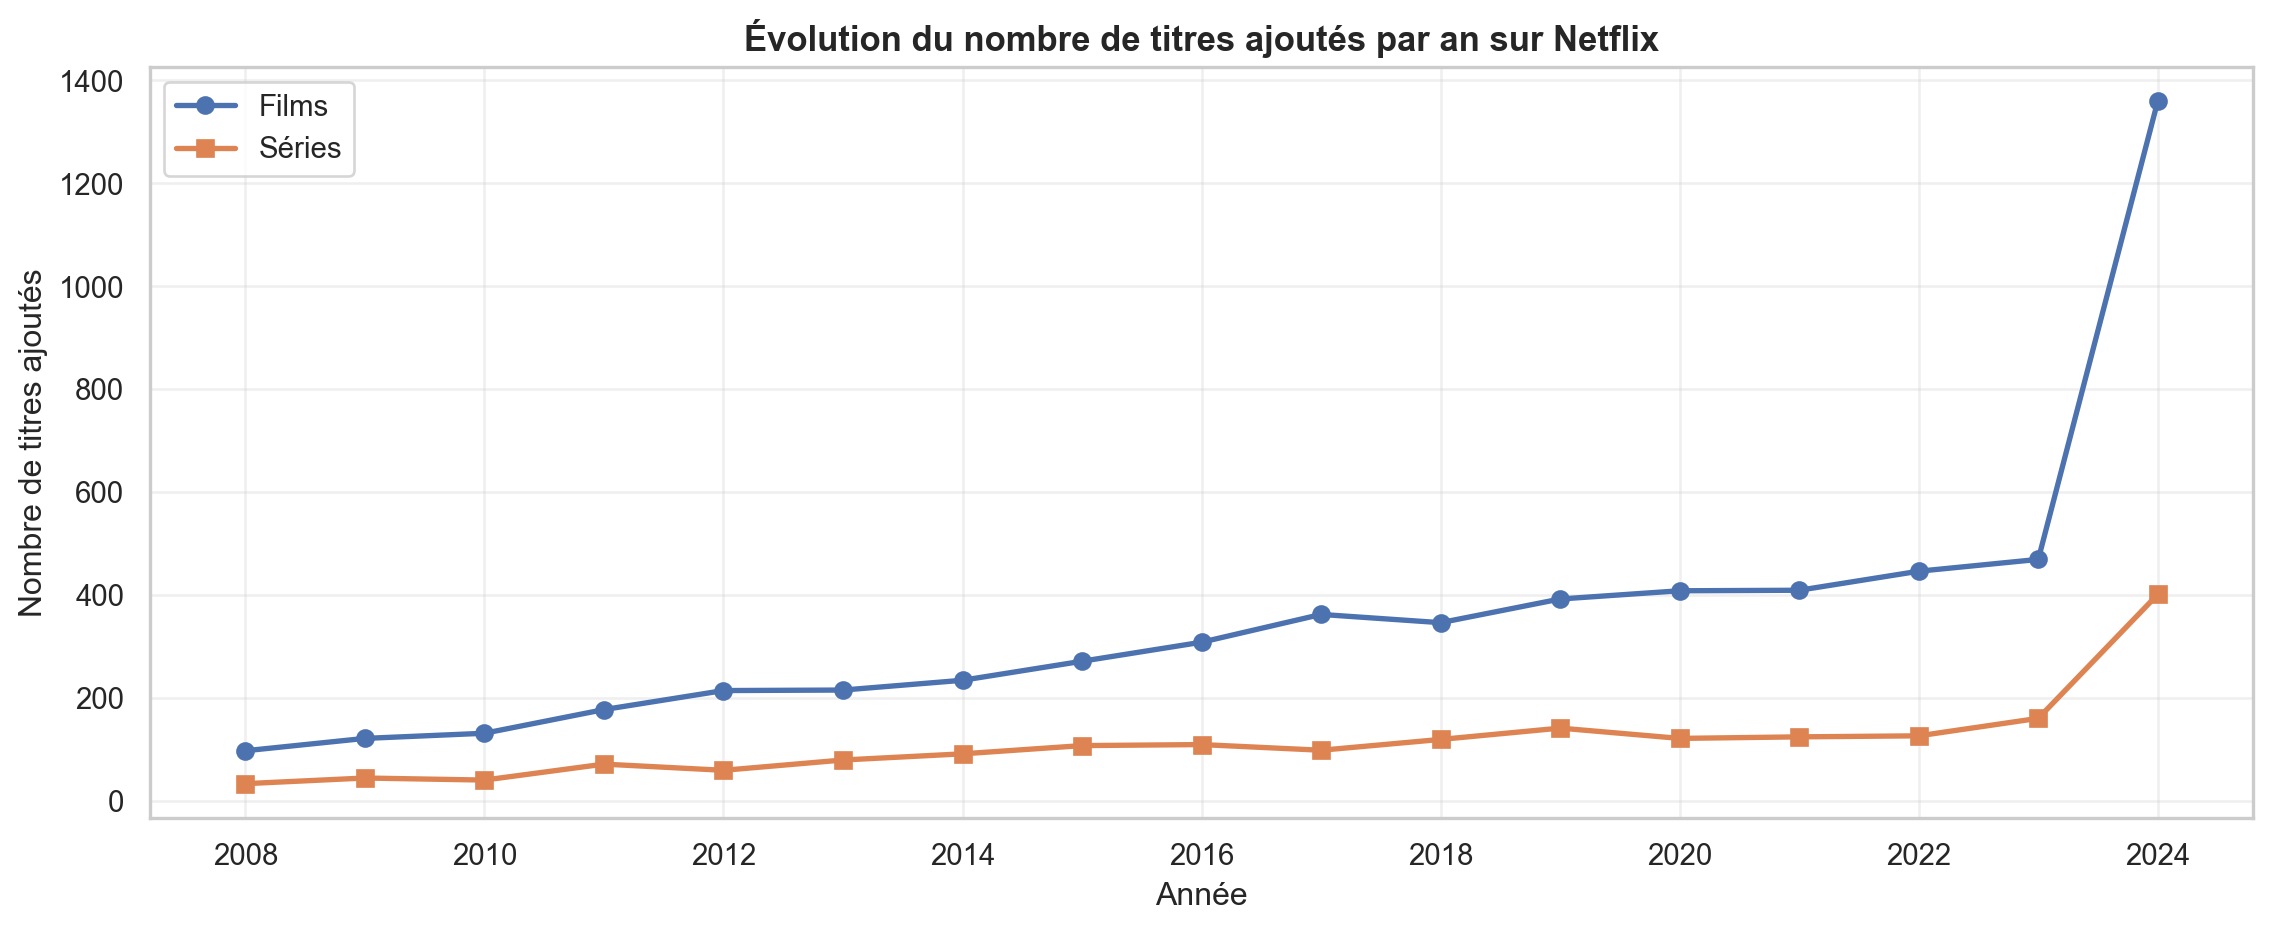

In [37]:
# 3. Line plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(additions_par_an.index, additions_par_an["Movie"], 
        marker="o", label="Films", linewidth=2)
ax.plot(additions_par_an.index, additions_par_an["TV Show"], 
        marker="s", label="Séries", linewidth=2)

ax.set_xlabel("Année")
ax.set_ylabel("Nombre de titres ajoutés")
ax.set_title("Évolution du nombre de titres ajoutés par an sur Netflix", 
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
#| eval: false
# TODO: Étape 4.3

In [39]:
top_genres = df_genres["genre"].value_counts().head(10)
print(top_genres)

genre
British TV Shows          555
Anime Series              542
Romantic Movies           534
Comedies                  528
Classic Movies            528
International TV Shows    518
Horror Movies             513
Stand-Up Comedy           505
Music & Musicals          505
Korean TV Shows           504
Name: count, dtype: int64


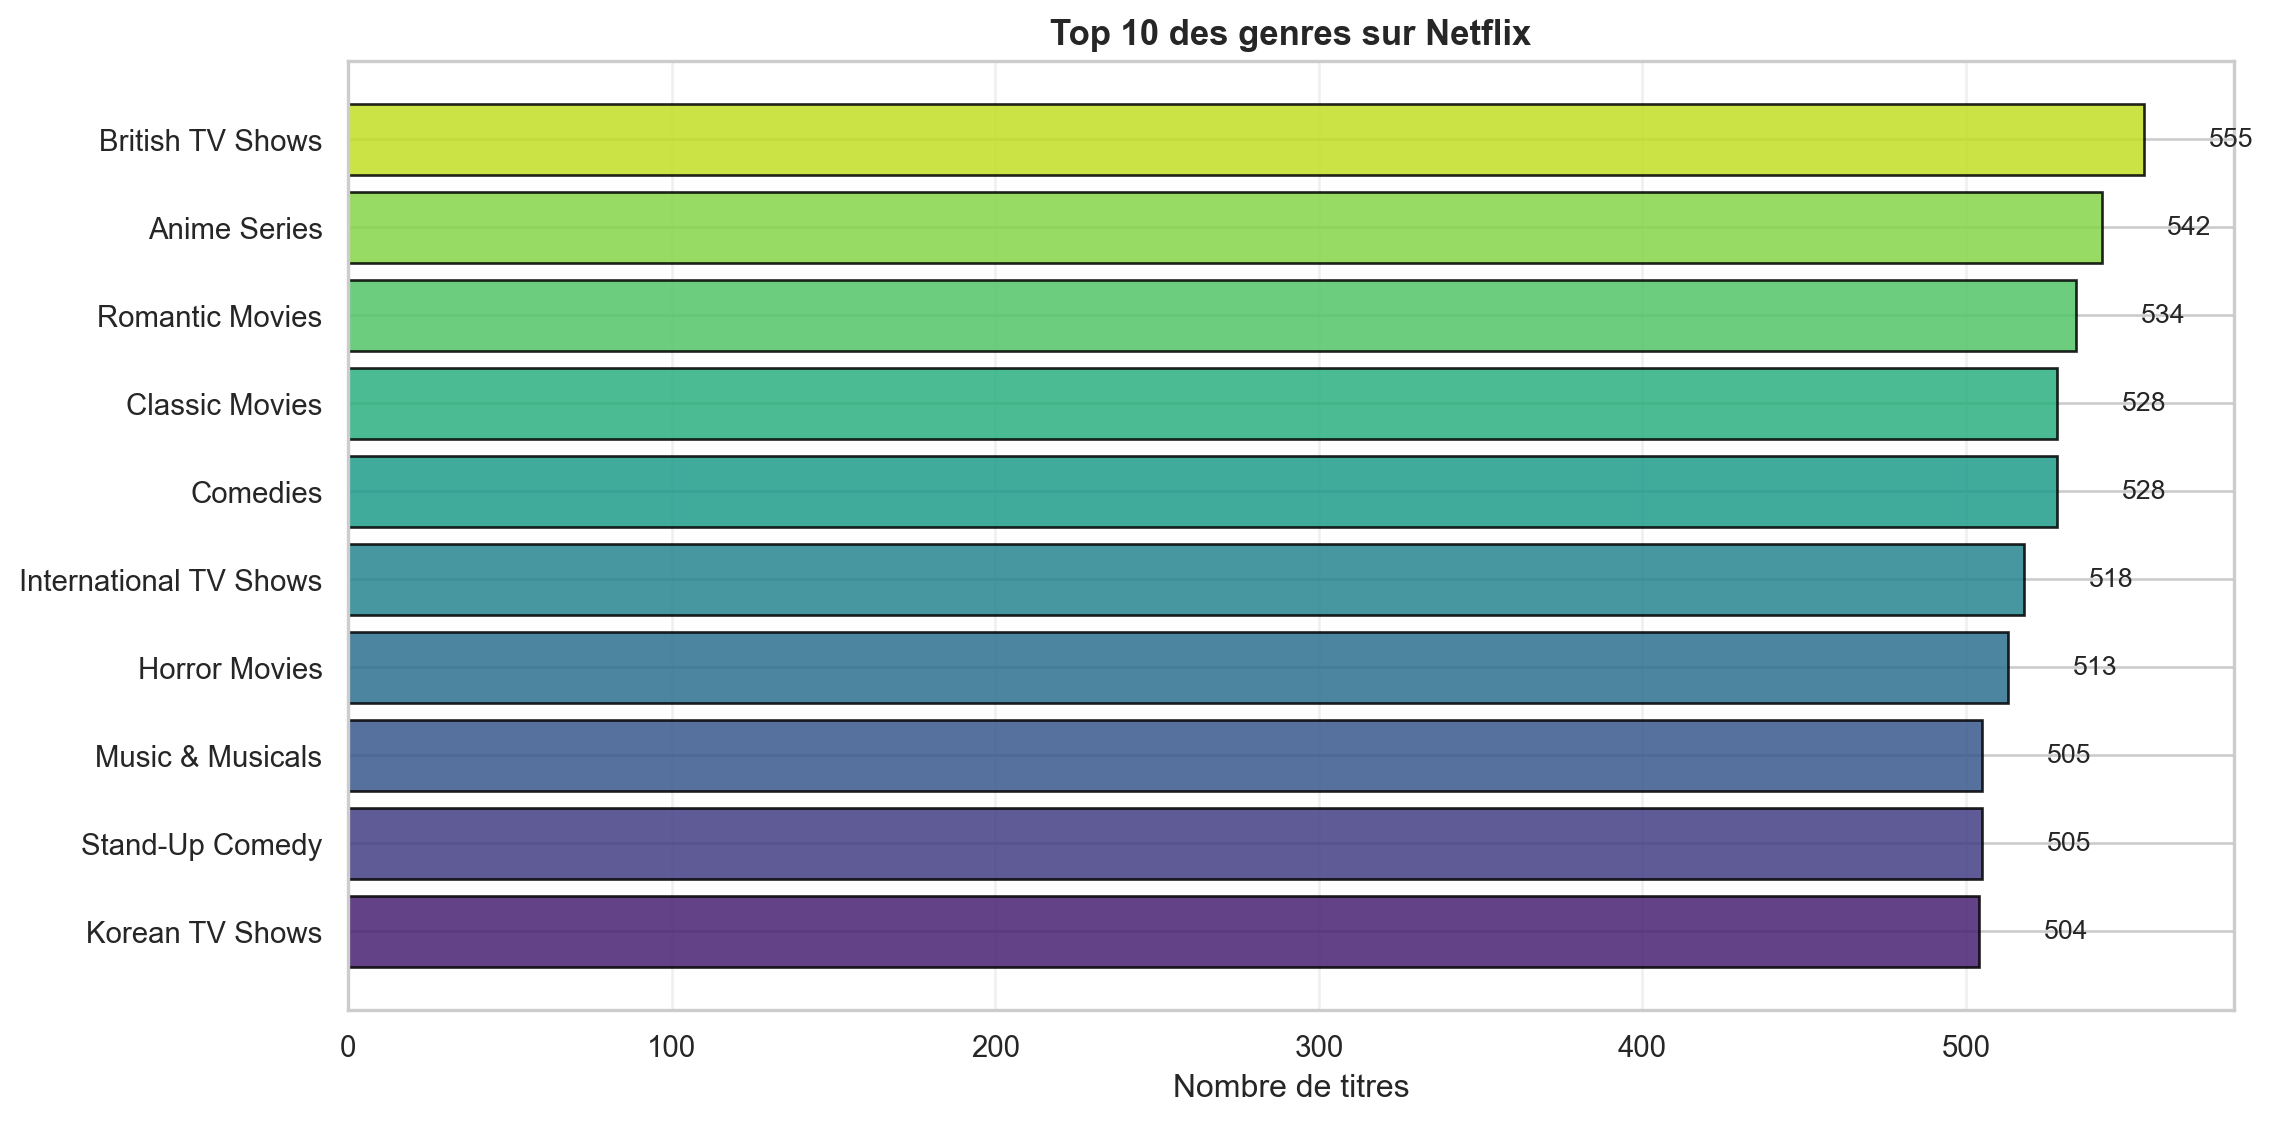

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

# Inverser pour que le plus gros soit en haut
top_genres_sorted = top_genres.sort_values(ascending=True)

ax.barh(top_genres_sorted.index, top_genres_sorted.values, 
        color=sns.color_palette("viridis", 10), edgecolor="black", alpha=0.85)

ax.set_xlabel("Nombre de titres")
ax.set_title("Top 10 des genres sur Netflix", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

# Annoter chaque barre
for i, v in enumerate(top_genres_sorted.values):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [41]:
#| eval: false
# TODO: Étape 4.4

In [42]:
# 1. Top 10 pays
top10_pays = df_countries["pays"].value_counts().head(10).index.tolist()
print(f"Top 10 pays : {top10_pays}")

Top 10 pays : ['United States', 'India', 'United Kingdom', 'Japan', 'South Korea', 'France', 'Canada', 'Germany', 'Spain', 'Mexico']


In [43]:
# 2. Répartition films/séries pour ces pays
pays_type = (
    df_countries[df_countries["pays"].isin(top10_pays)]
    .groupby(["pays", "type"]).size().unstack(fill_value=0)
)
pays_type = pays_type.loc[top10_pays]  # garder l'ordre
print(pays_type)

type            Movie  TV Show
pays                          
United States    2605      841
India             846      275
United Kingdom    740      226
Japan             571      181
South Korea       449      137
France            370      117
Canada            352      120
Germany           292       94
Spain             278       96
Mexico            243       86


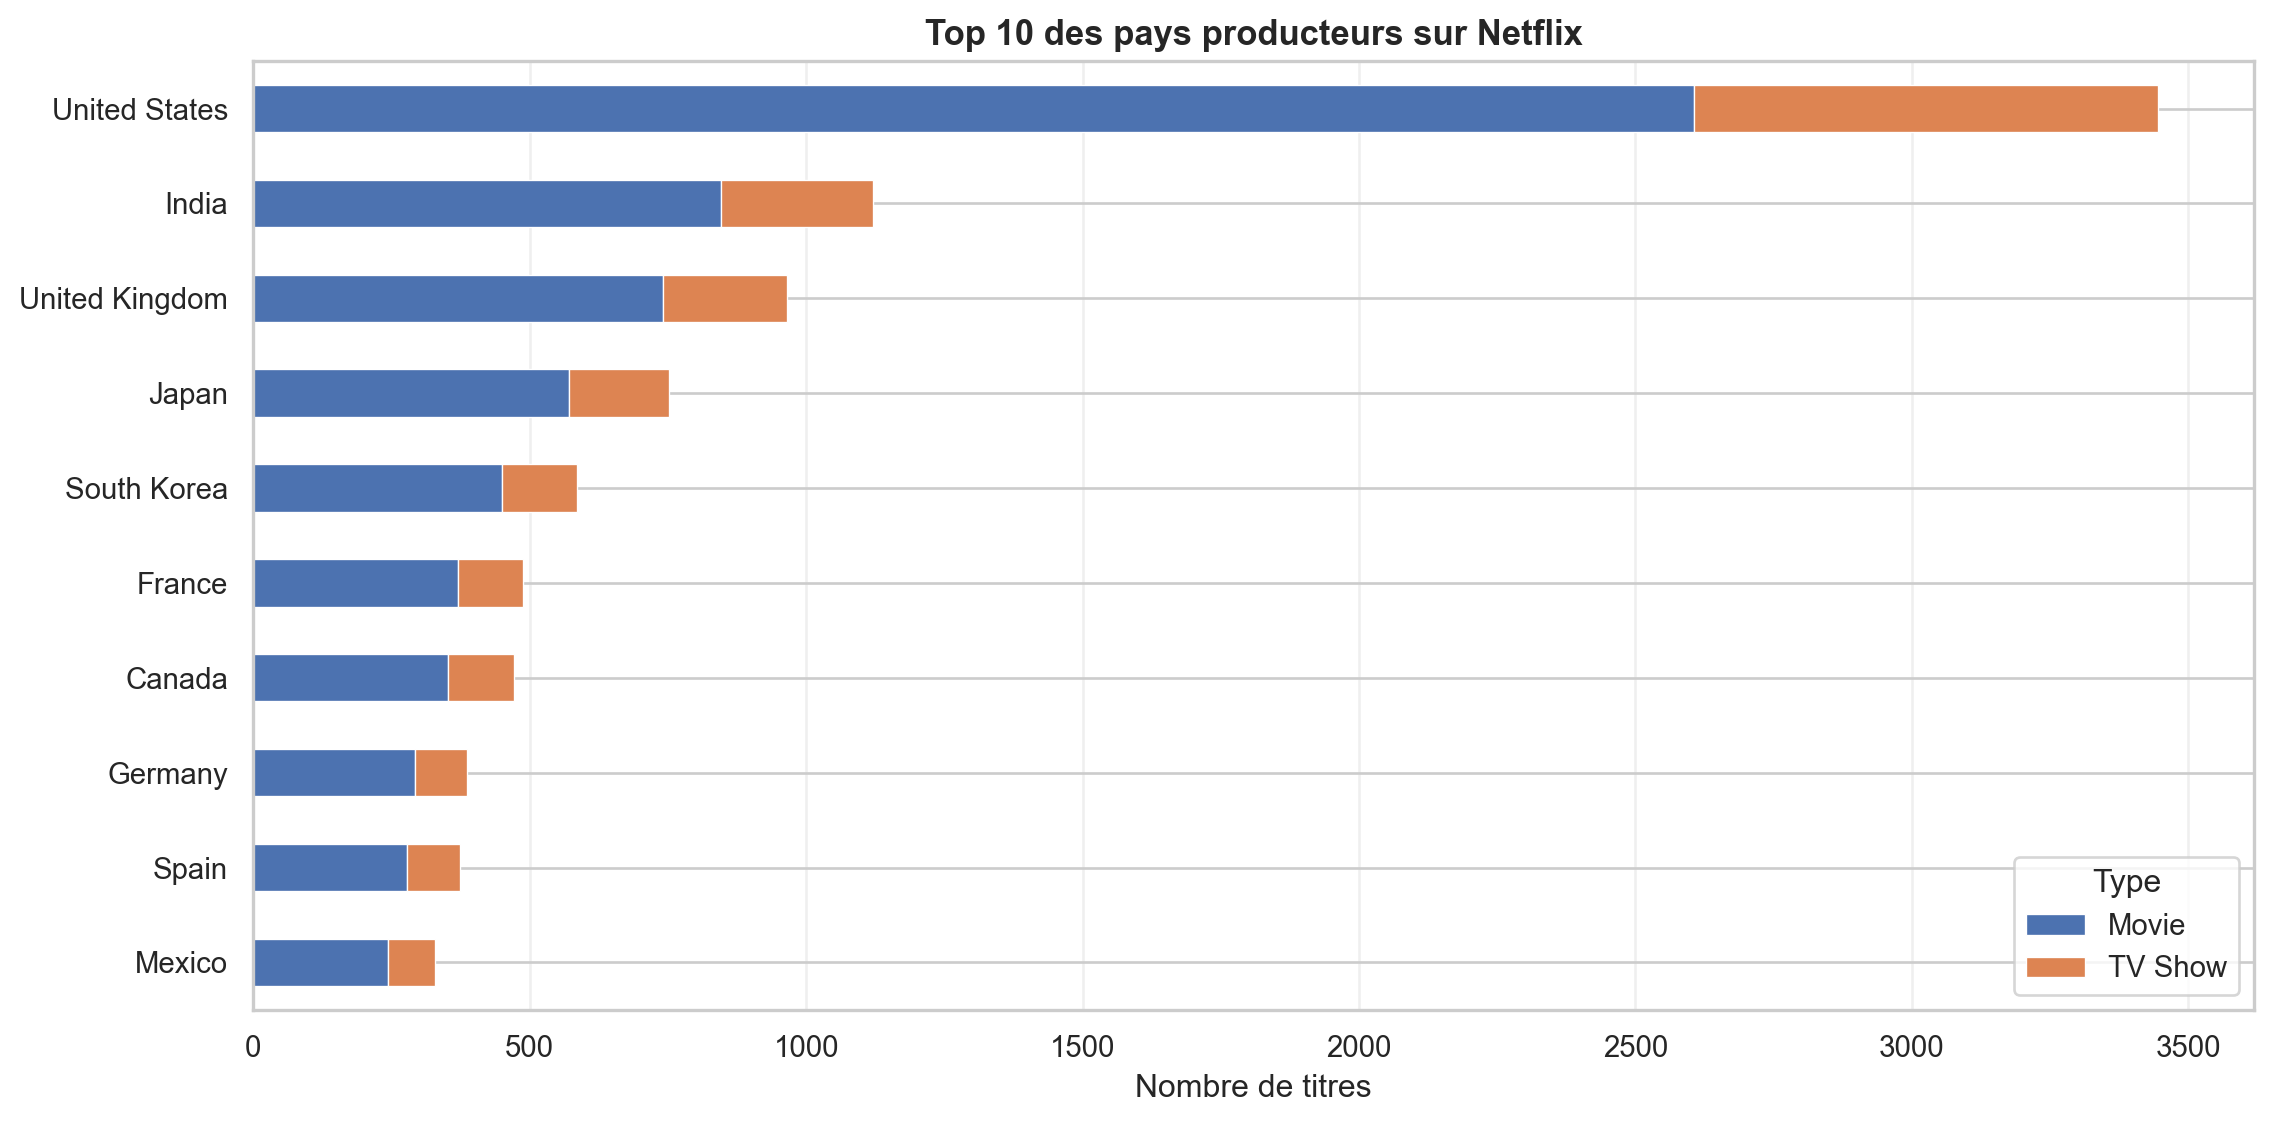

In [44]:
# 3. Bar chart empilé
fig, ax = plt.subplots(figsize=(12, 6))

pays_type_sorted = pays_type.iloc[::-1]  # inverser pour l'affichage
pays_type_sorted.plot(kind="barh", stacked=True, ax=ax, 
                       color=["#4C72B0", "#DD8452"],
                       edgecolor="white", linewidth=0.5)

ax.set_xlabel("Nombre de titres")
ax.set_ylabel("")
ax.set_title("Top 10 des pays producteurs sur Netflix", 
             fontsize=13, fontweight="bold")
ax.legend(title="Type", loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [45]:
#| eval: false
# TODO: Étape 4.5

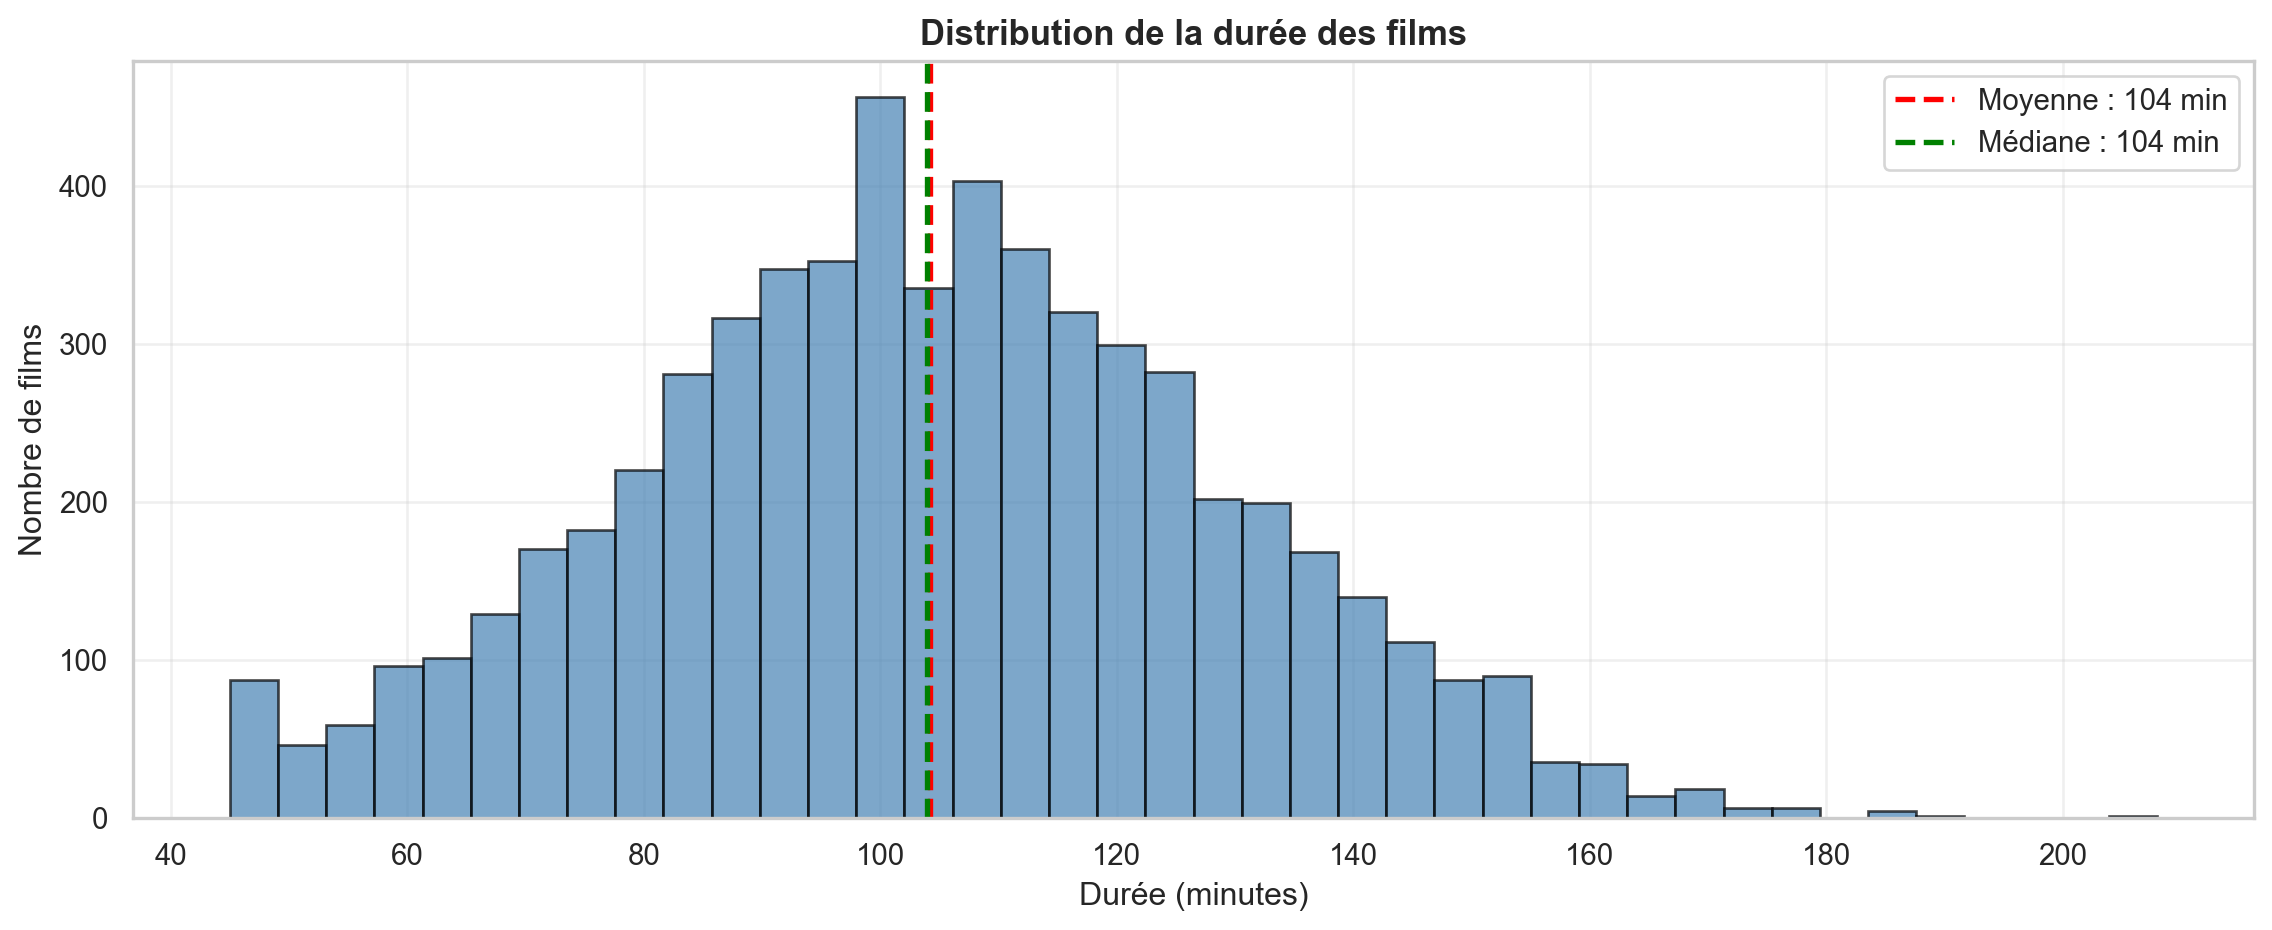

Durée typique d'un film : autour de 104 minutes
80% des films durent entre 71 et 137 minutes


In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["duration_min"].dropna(), bins=40, color="steelblue", 
        edgecolor="black", alpha=0.7)

moy = df["duration_min"].mean()
med = df["duration_min"].median()

ax.axvline(moy, color="red", linestyle="--", linewidth=2, 
           label=f"Moyenne : {moy:.0f} min")
ax.axvline(med, color="green", linestyle="--", linewidth=2,
           label=f"Médiane : {med:.0f} min")

ax.set_xlabel("Durée (minutes)")
ax.set_ylabel("Nombre de films")
ax.set_title("Distribution de la durée des films", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Durée typique d'un film : autour de {med:.0f} minutes")
print(f"80% des films durent entre {df['duration_min'].quantile(0.1):.0f} et {df['duration_min'].quantile(0.9):.0f} minutes")

In [47]:
#| eval: false
# TODO: Étape 4.6

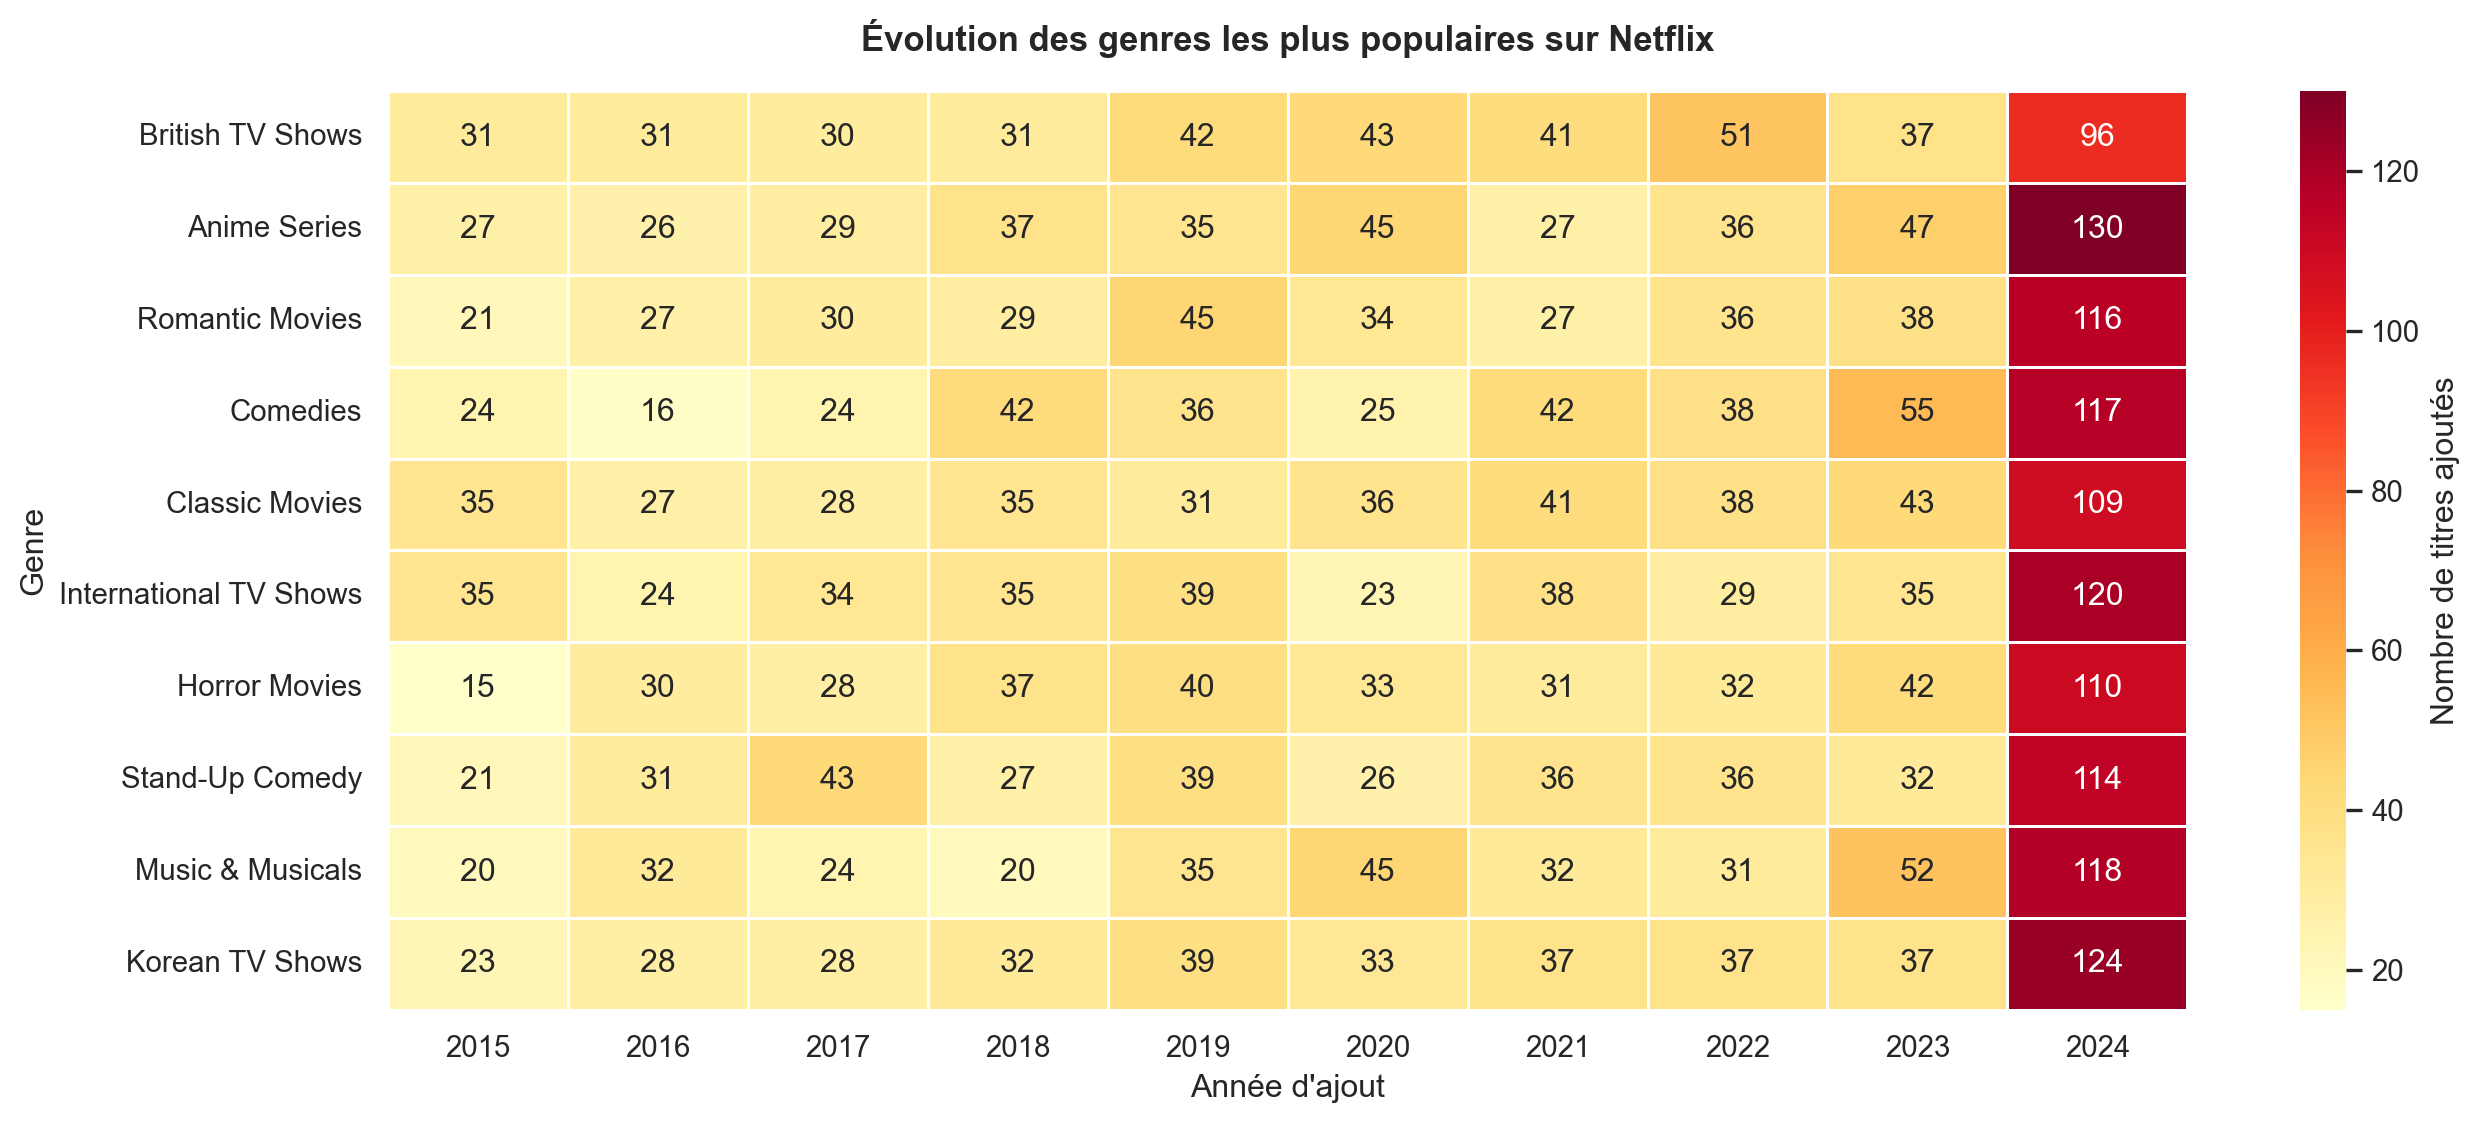

In [48]:
# 1-2. Préparer la matrice
top10 = df_genres["genre"].value_counts().head(10).index.tolist()

genre_year = (
    df_genres[df_genres["genre"].isin(top10) & (df_genres["year_added"] >= 2015)]
    .groupby(["genre", "year_added"]).size()
    .unstack(fill_value=0)
)
# Réordonner les genres par popularité totale
genre_year = genre_year.loc[top10]

# 3. Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(genre_year, annot=True, fmt="d", cmap="YlOrRd",
            cbar_kws={"label": "Nombre de titres ajoutés"}, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Évolution des genres les plus populaires sur Netflix",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Année d'ajout")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

In [49]:
#| eval: false
# TODO: Étape 5 — Dashboard

C:\Users\loich\AppData\Local\Temp\ipykernel_14912\2569241230.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


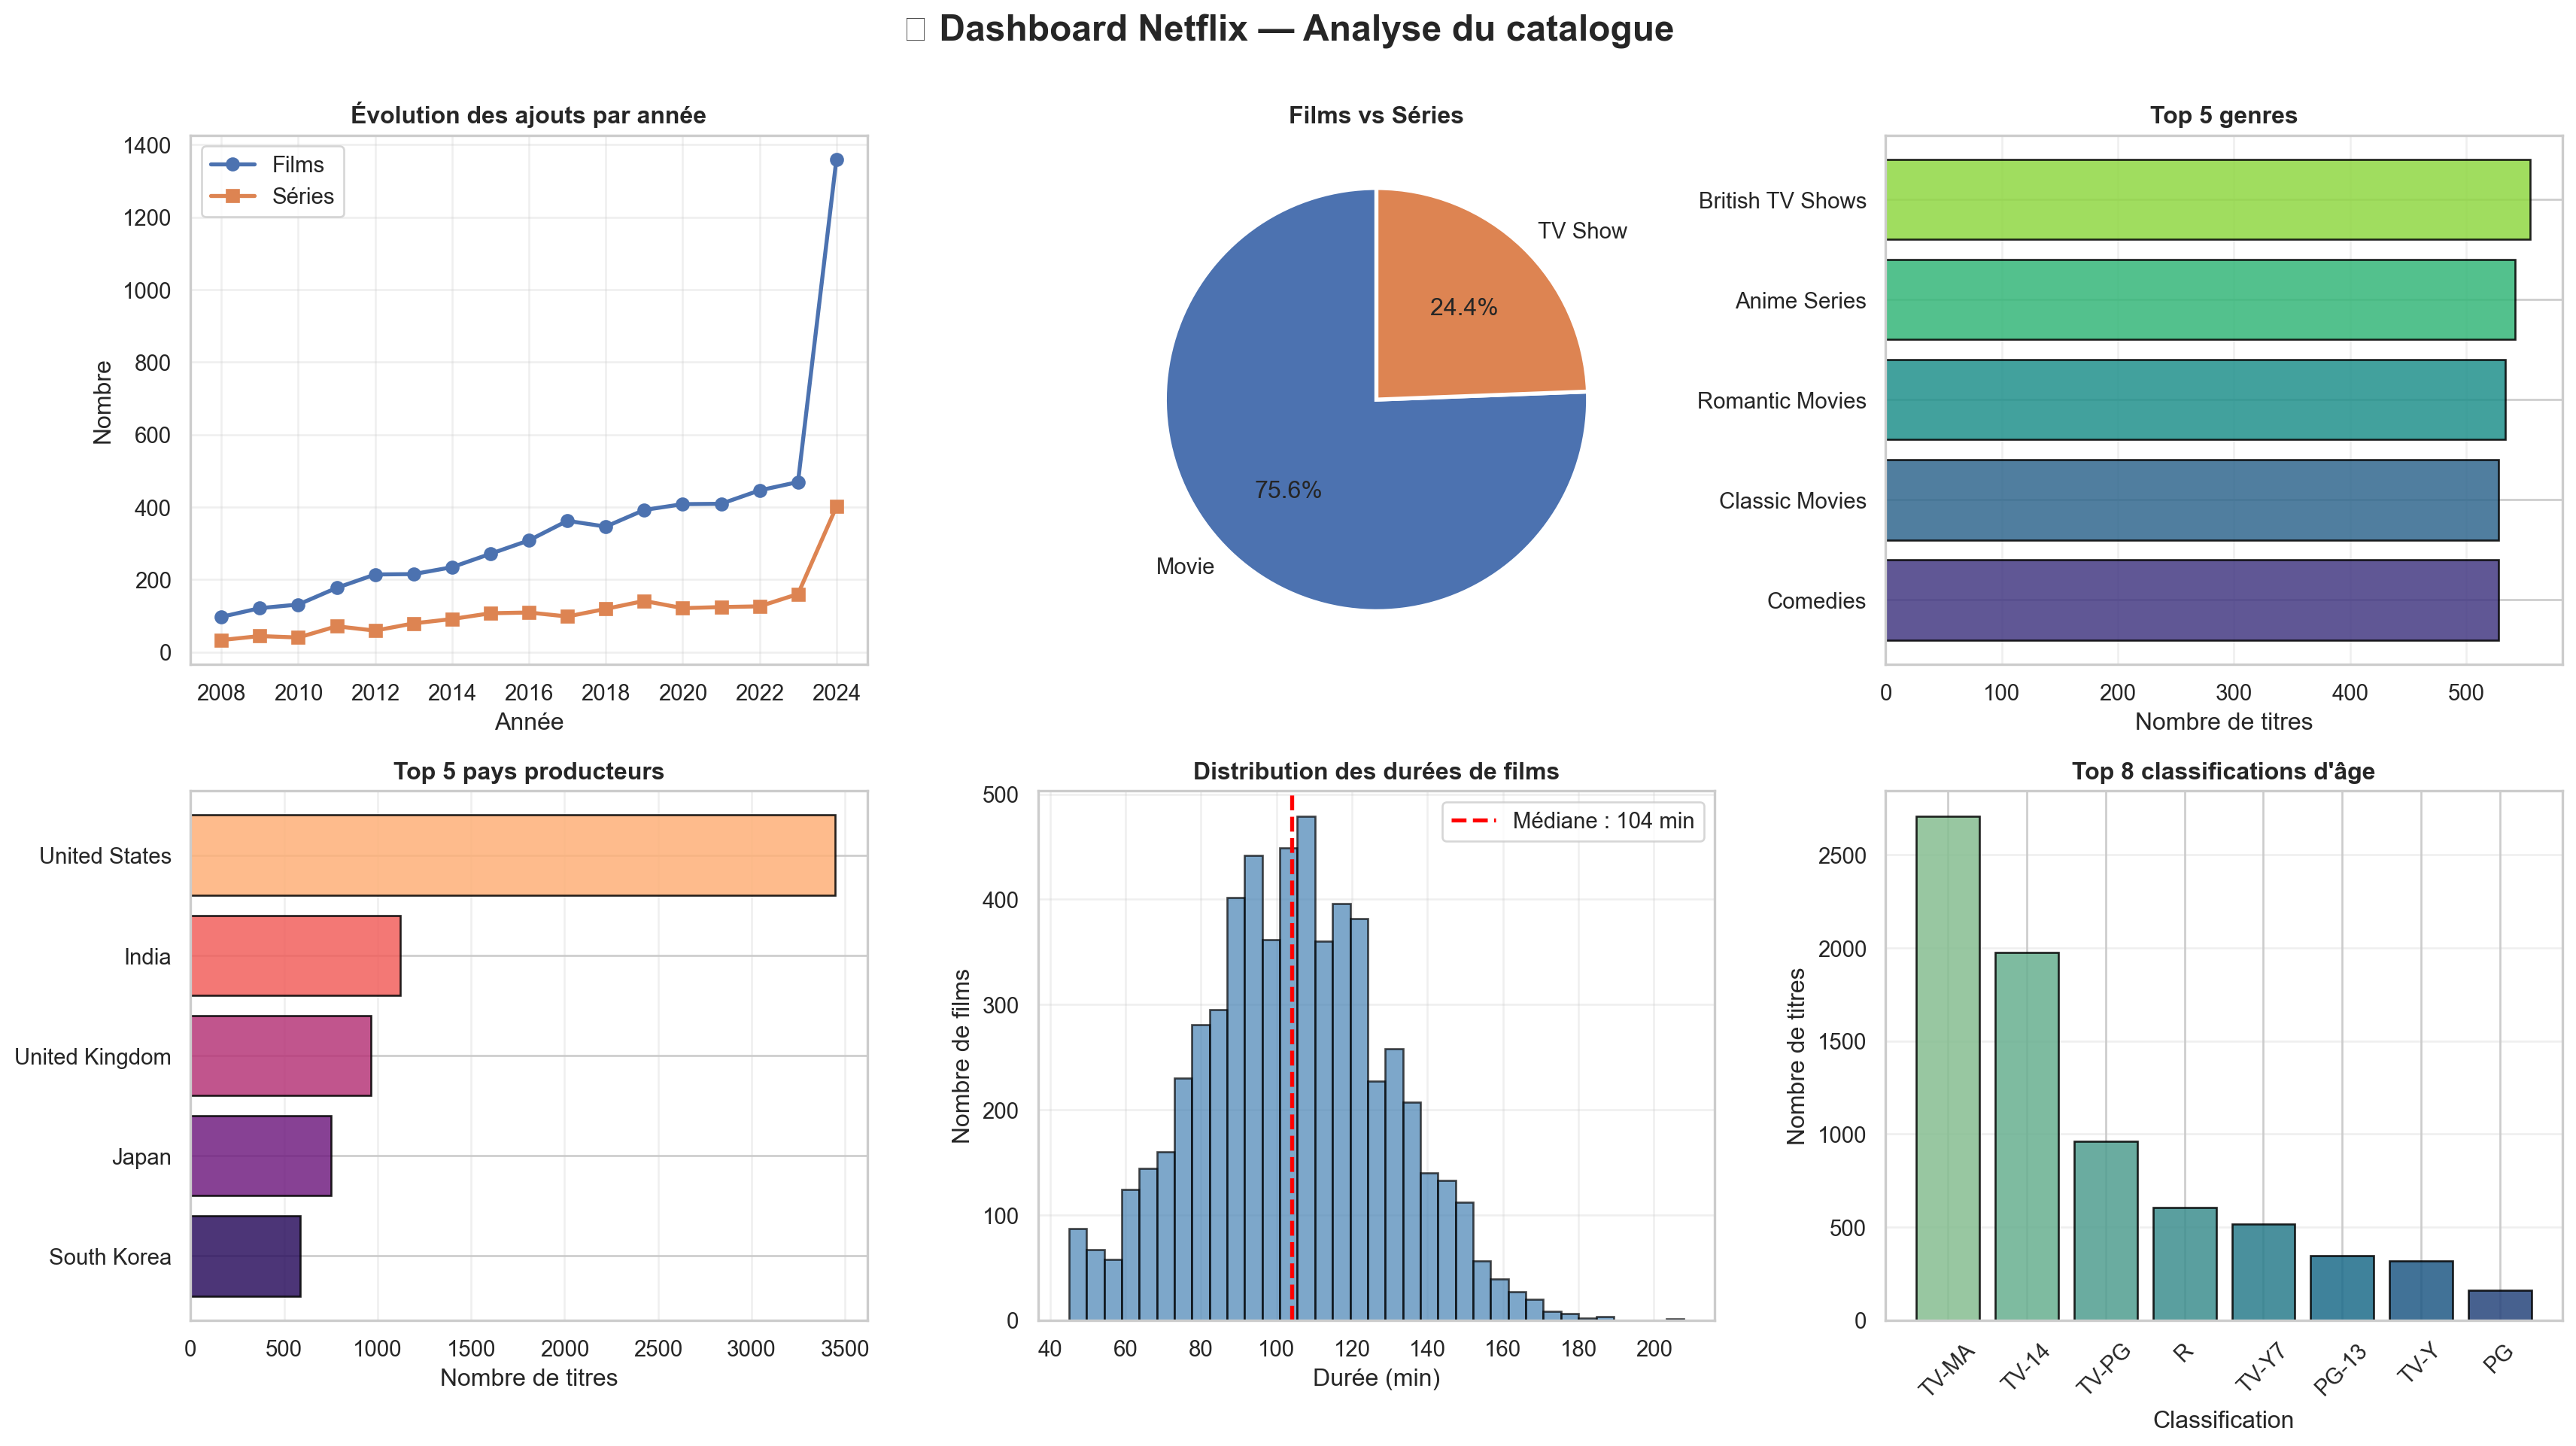

In [50]:
# Préparer toutes les données
additions_par_an = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
top5_genres = df_genres["genre"].value_counts().head(5).sort_values(ascending=True)
top5_pays = df_countries["pays"].value_counts().head(5).sort_values(ascending=True)

# Créer la figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ========== [0, 0] Évolution annuelle ==========
ax1 = axes[0, 0]
ax1.plot(additions_par_an.index, additions_par_an["Movie"], 
         marker="o", label="Films", linewidth=2, color="#4C72B0")
ax1.plot(additions_par_an.index, additions_par_an["TV Show"], 
         marker="s", label="Séries", linewidth=2, color="#DD8452")
ax1.set_title("Évolution des ajouts par année", fontweight="bold")
ax1.set_xlabel("Année")
ax1.set_ylabel("Nombre")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ========== [0, 1] Pie chart films vs séries ==========
ax2 = axes[0, 1]
counts = df["type"].value_counts()
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax2.set_title("Films vs Séries", fontweight="bold")

# ========== [0, 2] Top 5 genres ==========
ax3 = axes[0, 2]
ax3.barh(top5_genres.index, top5_genres.values, 
         color=sns.color_palette("viridis", 5), edgecolor="black", alpha=0.85)
ax3.set_title("Top 5 genres", fontweight="bold")
ax3.set_xlabel("Nombre de titres")
ax3.grid(True, alpha=0.3, axis="x")

# ========== [1, 0] Top 5 pays ==========
ax4 = axes[1, 0]
ax4.barh(top5_pays.index, top5_pays.values,
         color=sns.color_palette("magma", 5), edgecolor="black", alpha=0.85)
ax4.set_title("Top 5 pays producteurs", fontweight="bold")
ax4.set_xlabel("Nombre de titres")
ax4.grid(True, alpha=0.3, axis="x")

# ========== [1, 1] Distribution durée films ==========
ax5 = axes[1, 1]
ax5.hist(df["duration_min"].dropna(), bins=35, color="steelblue", 
         edgecolor="black", alpha=0.7)
med = df["duration_min"].median()
ax5.axvline(med, color="red", linestyle="--", linewidth=2,
            label=f"Médiane : {med:.0f} min")
ax5.set_title("Distribution des durées de films", fontweight="bold")
ax5.set_xlabel("Durée (min)")
ax5.set_ylabel("Nombre de films")
ax5.legend()
ax5.grid(True, alpha=0.3)

# ========== [1, 2] Classifications d'âge ==========
ax6 = axes[1, 2]
rating_counts = df["rating"].value_counts().head(8)
ax6.bar(rating_counts.index, rating_counts.values,
        color=sns.color_palette("crest", len(rating_counts)), 
        edgecolor="black", alpha=0.85)
ax6.set_title("Top 8 classifications d'âge", fontweight="bold")
ax6.set_xlabel("Classification")
ax6.set_ylabel("Nombre de titres")
ax6.tick_params(axis="x", rotation=45)
ax6.grid(True, alpha=0.3, axis="y")

# Titre global
fig.suptitle("📊 Dashboard Netflix — Analyse du catalogue", 
             fontsize=18, fontweight="bold", y=1.00)

plt.tight_layout()

# Bonus : sauvegarder
# fig.savefig("dashboard_netflix.png", dpi=150, bbox_inches="tight")

plt.show()